<a href="https://colab.research.google.com/github/swatis1805/pizzahub/blob/main/ML_For_Hotel_Booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing The Libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [36]:
import warnings
warnings.filterwarnings('ignore')

from google.colab import files

uploaded = files.upload()

Saving final_hotel_booking.csv to final_hotel_booking (2).csv


In [37]:
import os

os.listdir('/content')


['.config',
 'final_hotel_booking (2).csv',
 'final_hotel_booking.csv',
 'final_hotel_booking (1).csv',
 'sample_data']

In [38]:
import pandas as pd

df = pd.read_csv('/content/final_hotel_booking.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,arrival_season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,2,0,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,2,0,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,7/2/2015,1,1,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,7/2/2015,1,1,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,7/3/2015,2,2,Summer


#Loading The Dataset

In [39]:
import os

print(os.listdir('/content'))

['.config', 'final_hotel_booking (2).csv', 'final_hotel_booking.csv', 'final_hotel_booking (1).csv', 'sample_data']


# Basic Preprocessing
1. Getting The Information About The Dataset.

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119385 entries, 0 to 119384
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119385 non-null  object 
 1   is_canceled                     119385 non-null  int64  
 2   lead_time                       119385 non-null  int64  
 3   arrival_date_year               119385 non-null  int64  
 4   arrival_date_month              119385 non-null  object 
 5   arrival_date_week_number        119385 non-null  int64  
 6   arrival_date_day_of_month       119385 non-null  int64  
 7   stays_in_weekend_nights         119385 non-null  int64  
 8   stays_in_week_nights            119385 non-null  int64  
 9   adults                          119385 non-null  int64  
 10  children                        119385 non-null  int64  
 11  babies                          119385 non-null  int64  
 12  meal            

**Observations**
- From the above analysis, it is cleared that dataset contains 35 attributes containing different types of different datatypes.
- From the dataset, it is cleared that some attributes have many missing values that we need to take care of for better analysis.

2. Finding The Missing Values

In [41]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Filling The Missing Values

In [42]:
df['country'].fillna(df['country'].mode()[0], inplace=True) # Here we are using the mode imputation technique to fill the missing values

In [43]:
df['agent'] = df['agent'].fillna(0)
df['children'].fillna(0, inplace=True)

**Observations**
- We are dropping the company columns because it only have approximately 6% of values. So we cannot impute the values also as it creates noise in the data. Better to drop it.

In [44]:
df.drop('company', axis=1, inplace=True)

KeyError: "['company'] not found in axis"

Checking For The Missing Values Again

In [45]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


3. Checking For The Duplicates Values

In [46]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicates: {duplicate_count}")

Total Duplicates: 32020


4. Describe The Data

In [47]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights
count,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,...,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000,119385.000000
mean,0.370415,104.012983,2016.156569,27.165498,15.798358,0.927554,2.500239,1.856406,0.103807,0.007790,...,0.087121,0.137086,0.221075,74.828127,2.321246,101.787589,0.062520,0.571370,1.968003,3.425087
std,0.482918,106.864215,0.707470,13.605022,8.780893,0.998543,1.908165,0.579267,0.397533,0.089334,...,0.844354,1.497458,0.652267,107.142147,17.595083,48.153228,0.245296,0.792808,0.720867,2.517925
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,7.000000,0.000000,69.290000,0.000000,0.000000,2.000000,2.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,0.000000,94.560000,0.000000,0.000000,2.000000,3.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,152.000000,0.000000,126.000000,0.000000,1.000000,2.000000,4.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,3.000000,2.000000,...,26.000000,72.000000,21.000000,535.000000,391.000000,510.000000,8.000000,5.000000,55.000000,30.000000


**Observations**
- From The above analysis, it is cleared that some of the attributes contains outliers (extreme values).
- We need to take care of the outliers for better analysis.

5. Checking For The Outliers

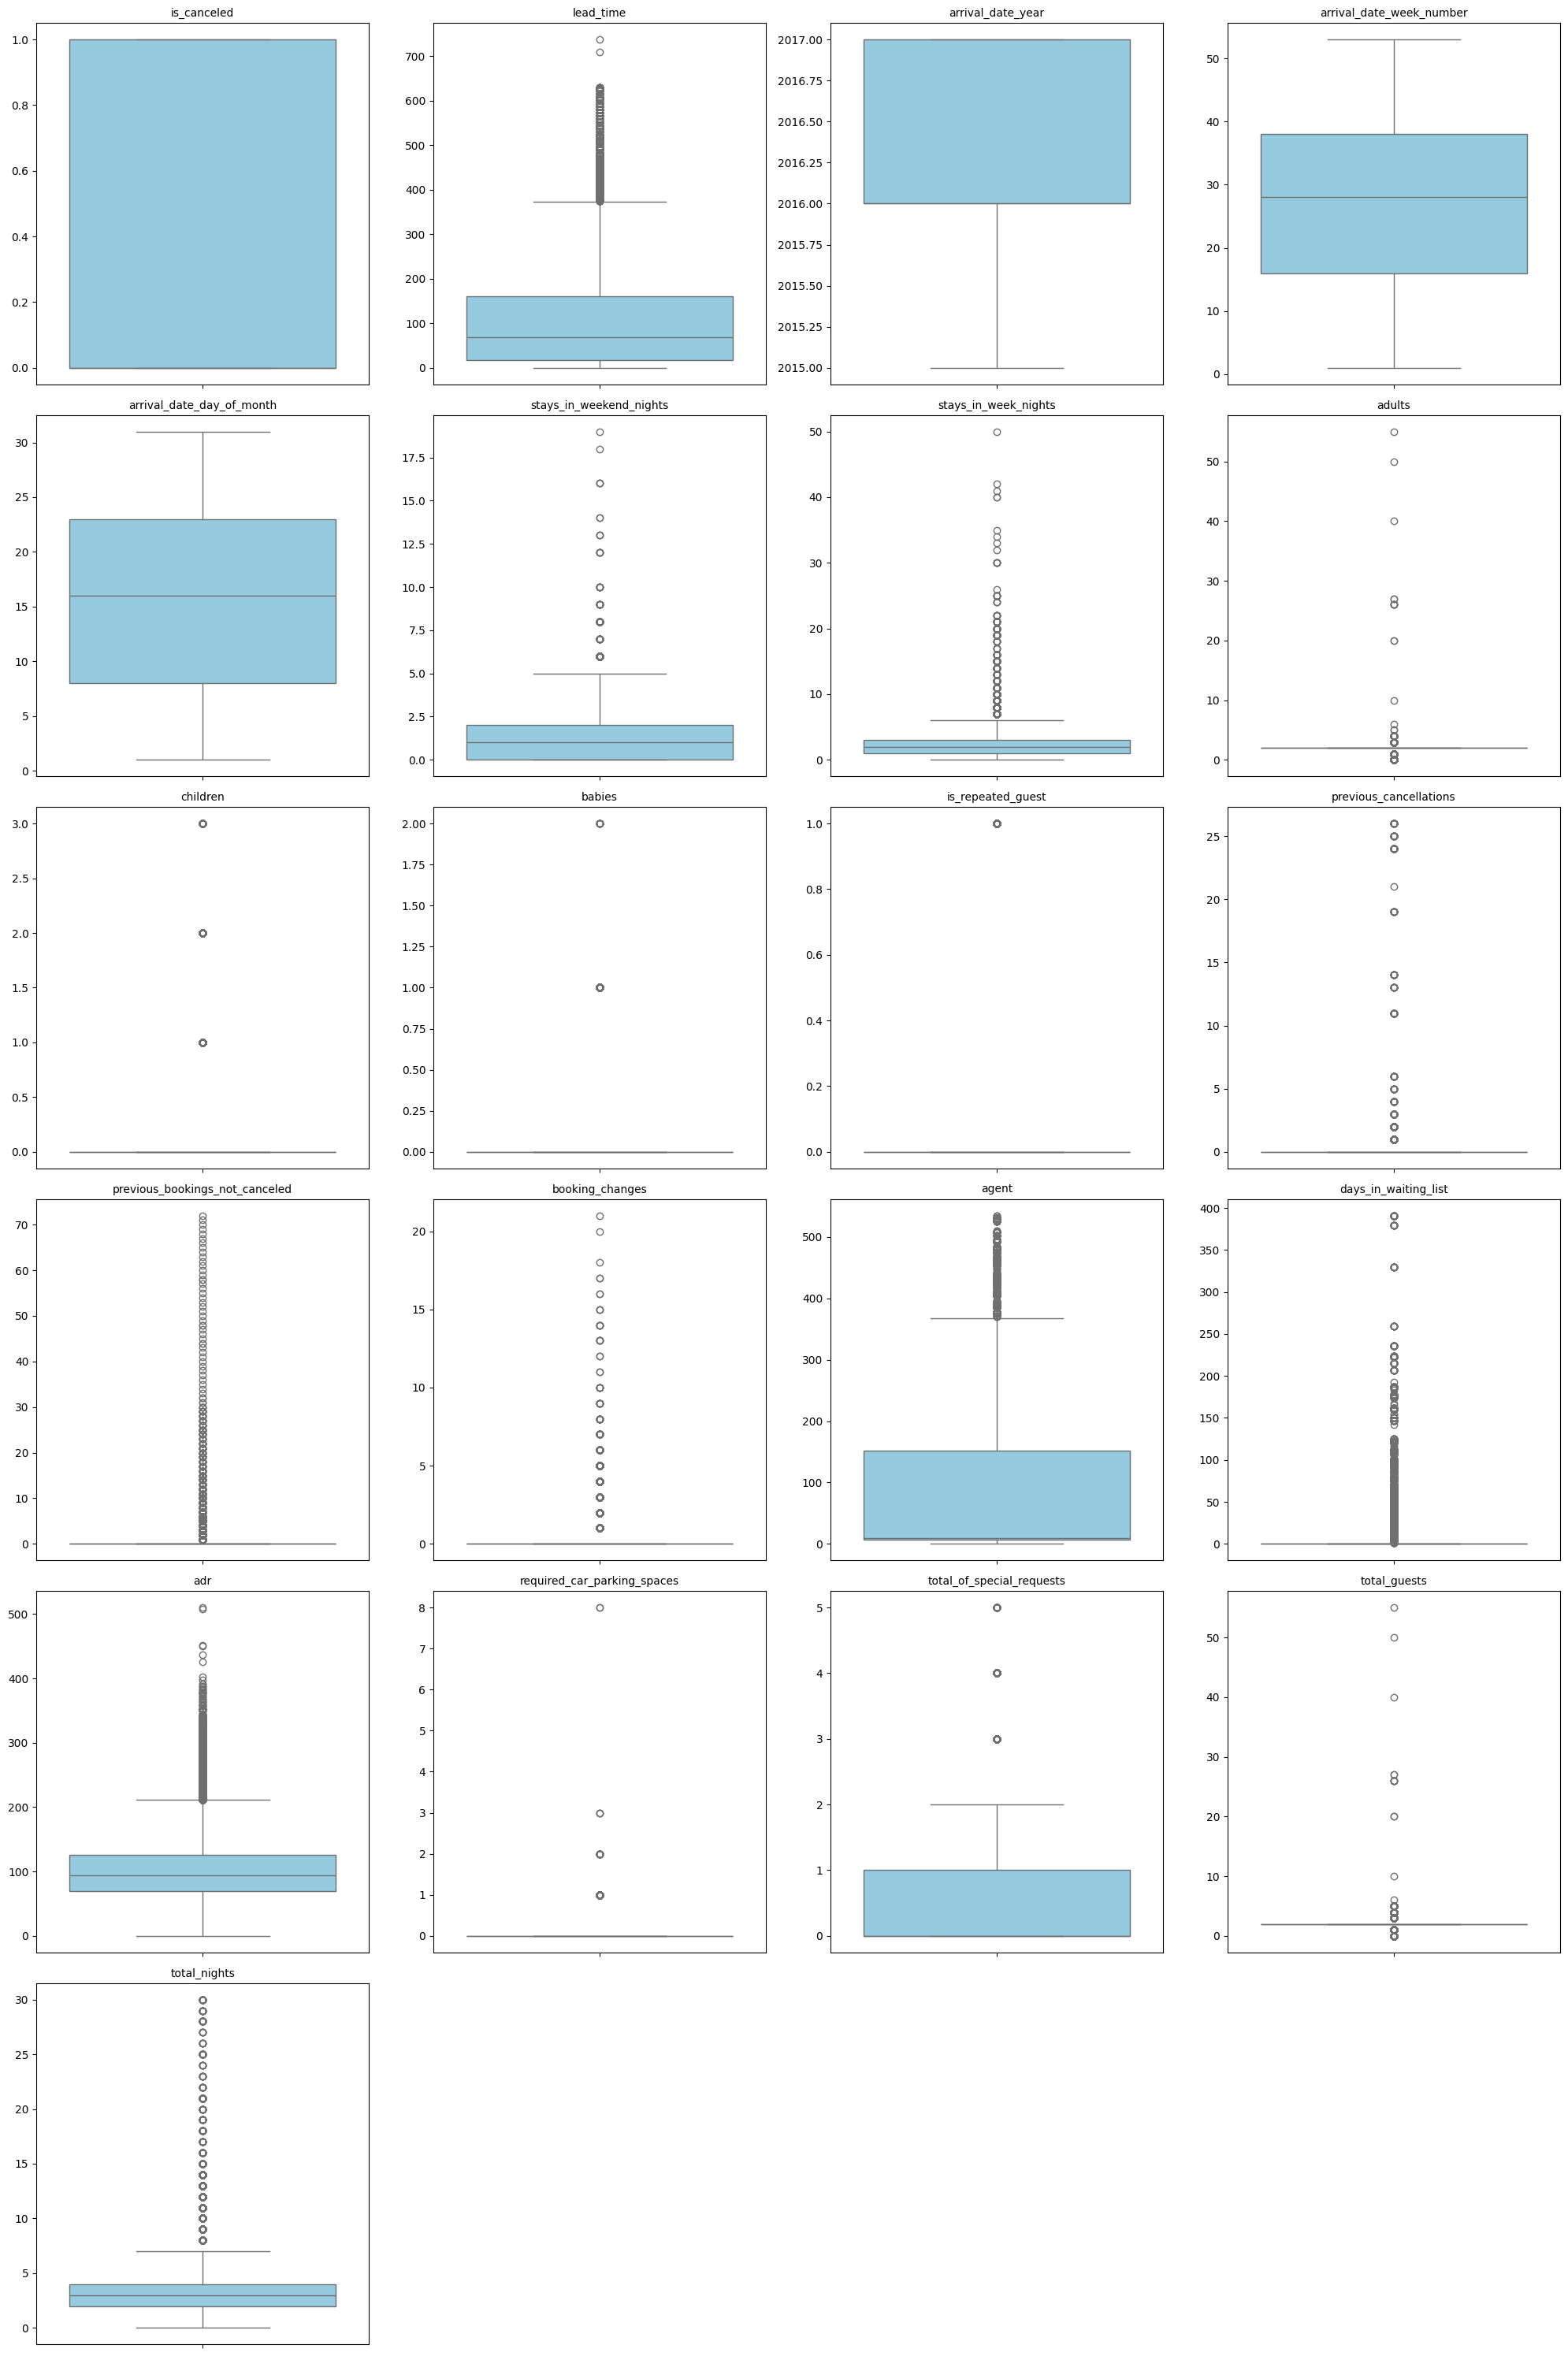

In [48]:
# Select all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set figure size dynamically
n_cols = 4  # Number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

# Plot boxplots
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel("")

plt.tight_layout()
plt.show()

**Observations**
- From The Above analysis, it is cleared that noticeable outliers are mainly found in the **adr** and **children** and **lead_time** columns, which will be investigated further before model training.
- While, most of the numeric features show outliers, but these values represent actual customer booking behavior and are important for analysis

6. Handling The Outliers


In [49]:
print(df[['children', 'adr']].describe())


            children            adr
count  119385.000000  119385.000000
mean        0.103807     101.787589
std         0.397533      48.153228
min         0.000000       0.000000
25%         0.000000      69.290000
50%         0.000000      94.560000
75%         0.000000     126.000000
max         3.000000     510.000000


**Observations**
- There's the negative values for the ADR (Average Daily Rate) which is not possible for the Hotel Booking, we need to solve it.

Solving The Issue of Negative Values

In [50]:
# Number of negative ADR values
print("Negative ADR values:", (df['adr'] < 0).sum())

df[df['adr'] < 0]

Negative ADR values: 0


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,arrival_season


**Observations**
- As there's only one record with the negative values, we can easily remove that record from the dataset as it doesn't impact much with the model training.

In [51]:
df = df[df['adr'] >= 0].copy()

Outlier Treatment
- Since ADR have only one record with the highest value of 5400 we can simply remove it.
- For children we can also remove the extreme records.


In [52]:
# Remove extremely high ADR values (greater than 1000)
df = df[df['adr'] < 1000]

# Remove unrealistic number of children
df = df[df['children'] <= 3]

Verifying The Results After Outlier Treatment

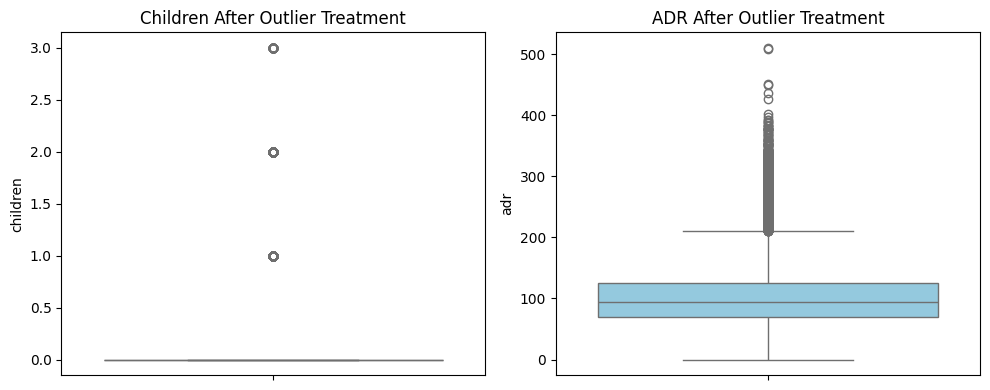

In [53]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
sns.boxplot(y=df['children'], color='skyblue')
plt.title('Children After Outlier Treatment')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['adr'], color='skyblue')
plt.title('ADR After Outlier Treatment')

plt.tight_layout()
plt.show()

7. Changing The Datatypes of Certain Columns.

In [54]:
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

8. Removing The Unnecessary Columns

In [56]:
columns_to_drop = [
    'name',
    'email',
    'phone-number',
    'credit_card'
]


df.drop(columns=columns_to_drop, inplace=True)
df.shape

KeyError: "['name', 'email', 'phone-number', 'credit_card'] not found in axis"

**Observations**
- We don't need the personal information because this is not useful for model training.

# Feature Engineering
1. Creating The **Total Guest** from the columns adults, babies and children. Creating this will helps to train the model with simple one feature instead of the 3 features.

In [57]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
print(df['total_guests'].describe())
df['total_guests'].value_counts().sort_index()

count    119385.000000
mean          1.968003
std           0.720867
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: total_guests, dtype: float64


,count
total_guests,
0,180
1,22581
2,82049
3,10495
4,3929
5,137
6,1
10,1
20,2


**Observations**
- Since 55 guests is not possible by any chance we need to take care of it.
- We first need to investigate the guests with the count greater than the 6.

In [58]:
df[df['total_guests'] > 6][
    ['adults', 'children', 'babies', 'hotel', 'market_segment', 'customer_type', 'is_canceled']
]

,adults,children,babies,hotel,market_segment,customer_type,is_canceled
1538,40,0,0,Resort Hotel,Direct,Group,1
1586,26,0,0,Resort Hotel,Offline TA/TO,Group,1
1642,50,0,0,Resort Hotel,Direct,Group,1
1751,26,0,0,Resort Hotel,Offline TA/TO,Group,1
1883,26,0,0,Resort Hotel,Offline TA/TO,Group,1
1916,27,0,0,Resort Hotel,Direct,Group,1
1961,27,0,0,Resort Hotel,Direct,Group,1
2002,26,0,0,Resort Hotel,Offline TA/TO,Group,1
2163,26,0,0,Resort Hotel,Offline TA/TO,Group,1
2172,55,0,0,Resort Hotel,Direct,Group,1


**Observations**
- From the above analysis it is clear that all the records with adults higher than six belongs to the Group Category of Customer Segment. It means this shows the legitimate group bookings such as corporate events, conferences, tours, or weddings, which are common in the hospitality industry. Therefore, these records were retained as they reflect valid business scenarios rather than data errors.

- Two records contained 9 and 10 babies in a single booking, which is highly unrealistic in a real-world hotel scenario. This should be need to take care of.

In [59]:
df = df[df['babies'] <= 2]

2. Total Nights
- Creating This Feature will helps to analyze the total stay for any specific customer. We don't need to enter the weekend nights and week nights

In [60]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
print(df['total_nights'].describe())

count    119385.000000
mean          3.427792
std           2.557225
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_nights, dtype: float64


**Observations**
- We need to investigate the 0 night bookings and 69 days stay as it is not possible in real time.

In [61]:
df[df['total_nights'] == 0][
    ['stays_in_weekend_nights', 'stays_in_week_nights',
     'hotel', 'customer_type', 'is_canceled']
]


,stays_in_weekend_nights,stays_in_week_nights,hotel,customer_type,is_canceled
0,0,0,Resort Hotel,Transient,0
1,0,0,Resort Hotel,Transient,0
167,0,0,Resort Hotel,Transient,0
168,0,0,Resort Hotel,Transient,0
196,0,0,Resort Hotel,Transient,0
...,...,...,...,...,...
115478,0,0,City Hotel,Transient-Party,0
117696,0,0,City Hotel,Transient,0
118024,0,0,City Hotel,Transient,0
118626,0,0,City Hotel,Transient-Party,0


**Observations**
- From the above analysis it is cleared that staying for 0 days having the type of Transient (short stay) customer segment which is valid for the customer who would check in and check out in the same day.

In [62]:
df[df['total_nights'] > 30][
    ['total_nights', 'hotel', 'customer_type',
     'market_segment', 'is_canceled']
]

,total_nights,hotel,customer_type,market_segment,is_canceled
1654,46,Resort Hotel,Transient,Online TA,0
3819,42,Resort Hotel,Transient,Offline TA/TO,1
3849,42,Resort Hotel,Transient,Offline TA/TO,0
5343,33,Resort Hotel,Transient,Corporate,1
9838,56,Resort Hotel,Transient,Offline TA/TO,1
14036,60,Resort Hotel,Transient,Direct,0
14037,69,Resort Hotel,Transient,Direct,0
20833,35,Resort Hotel,Contract,Offline TA/TO,0
31402,35,Resort Hotel,Transient,Offline TA/TO,0
32587,45,Resort Hotel,Transient,Direct,0


**Observations**
- From the above analysis it is clear that some bookings exceeds through the 30 days stay which is not possible for our specific use case. So I am restricting the bookings till the 30 days.

In [63]:
# Cap total_nights at 30 days
df['total_nights'] = df['total_nights'].clip(upper=30)
print(df['total_nights'].describe())

count    119385.000000
mean          3.425087
std           2.517925
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          30.000000
Name: total_nights, dtype: float64


3. Arrival Season
- In real time, hotel analyze the demand in the seasonal trends such as peak tourists season or season off. This feature also helps to analyze the seasonal bookings

In [64]:
def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    else:
        return 'Autumn'

df['arrival_season'] = df['arrival_date_month'].apply(get_season)
print(df['arrival_season'])

0         Summer
1         Summer
2         Summer
3         Summer
4         Summer
           ...  
119380    Summer
119381    Summer
119382    Summer
119383    Summer
119384    Summer
Name: arrival_season, Length: 119385, dtype: object


Checking the Cancellation Rate In Different Season

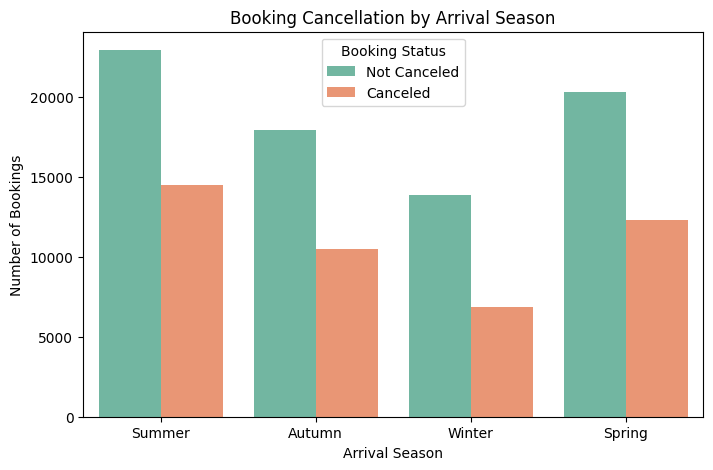

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='arrival_season',
    hue='is_canceled',
    palette='Set2'
)

plt.title('Booking Cancellation by Arrival Season')
plt.xlabel('Arrival Season')
plt.ylabel('Number of Bookings')
plt.legend(title='Booking Status', labels=['Not Canceled', 'Canceled'])

plt.show()

**Observations**
- From the above chart, it is clear that **Summer** season experiences the highest bookings with also highest cancellations suggesting the peak travel time while **Winter** experiences the lowest bookings and cancellations which suggest the season off for the hotels.

In [66]:
df.to_csv('final_hotel_booking.csv', index = False)

# Encoding The Categorical Features
- We will encode all the categorical features into the numerical features using Label Encoder for better training and accuracy

In [67]:
# Create a LabelEncoder object
le = LabelEncoder()

# Get all categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Label Encoding completed successfully!")

Label Encoding completed successfully!


Removing The Reservation Status
- This is important because it is like the cheatsheet which gives the clear answer to the model. As we are predicting the feature trends for it.

In [68]:
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

# Model Training
1. Selecting The Features needed to train our model

In [69]:
X = df.drop('is_canceled', axis = 1)
Y = df['is_canceled']

In [71]:
print(X.shape)
print(Y.shape)

(119385, 31)
(119385,)


2. Splitting Data into training and testing

In [70]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [72]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(95508, 31)
(23877, 31)
(95508,)
(23877,)


3. Training The Random Forest Classifier Model

In [73]:
model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')

In [79]:
model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

4. Predicting The Values

In [80]:
rf_pred = model.predict(X_test)

5. Testing The Accuracy on Testing Data

In [81]:
accuracy = accuracy_score(Y_test, rf_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8949197972944675


Finding The Other Metrics

In [82]:
print("Precision:", precision_score(Y_test, rf_pred))
print("Recall   :", recall_score(Y_test, rf_pred))
print("F1 Score :", f1_score(Y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, rf_pred))

print("\nClassification Report")
print(classification_report(Y_test, rf_pred))

Precision: 0.8875789985415654
Recall   : 0.8217621244514459
F1 Score : 0.8534034472684779

Confusion Matrix
[[14065   925]
 [ 1584  7303]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     14990
           1       0.89      0.82      0.85      8887

    accuracy                           0.89     23877
   macro avg       0.89      0.88      0.89     23877
weighted avg       0.89      0.89      0.89     23877



Plotting The Confusion Matrix For It

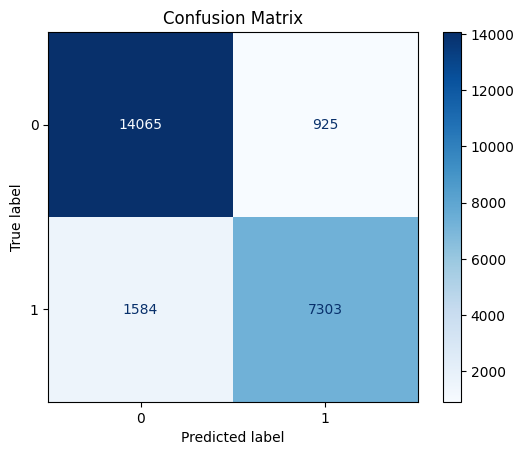

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

7. Plotting The Important Features for Cancellation

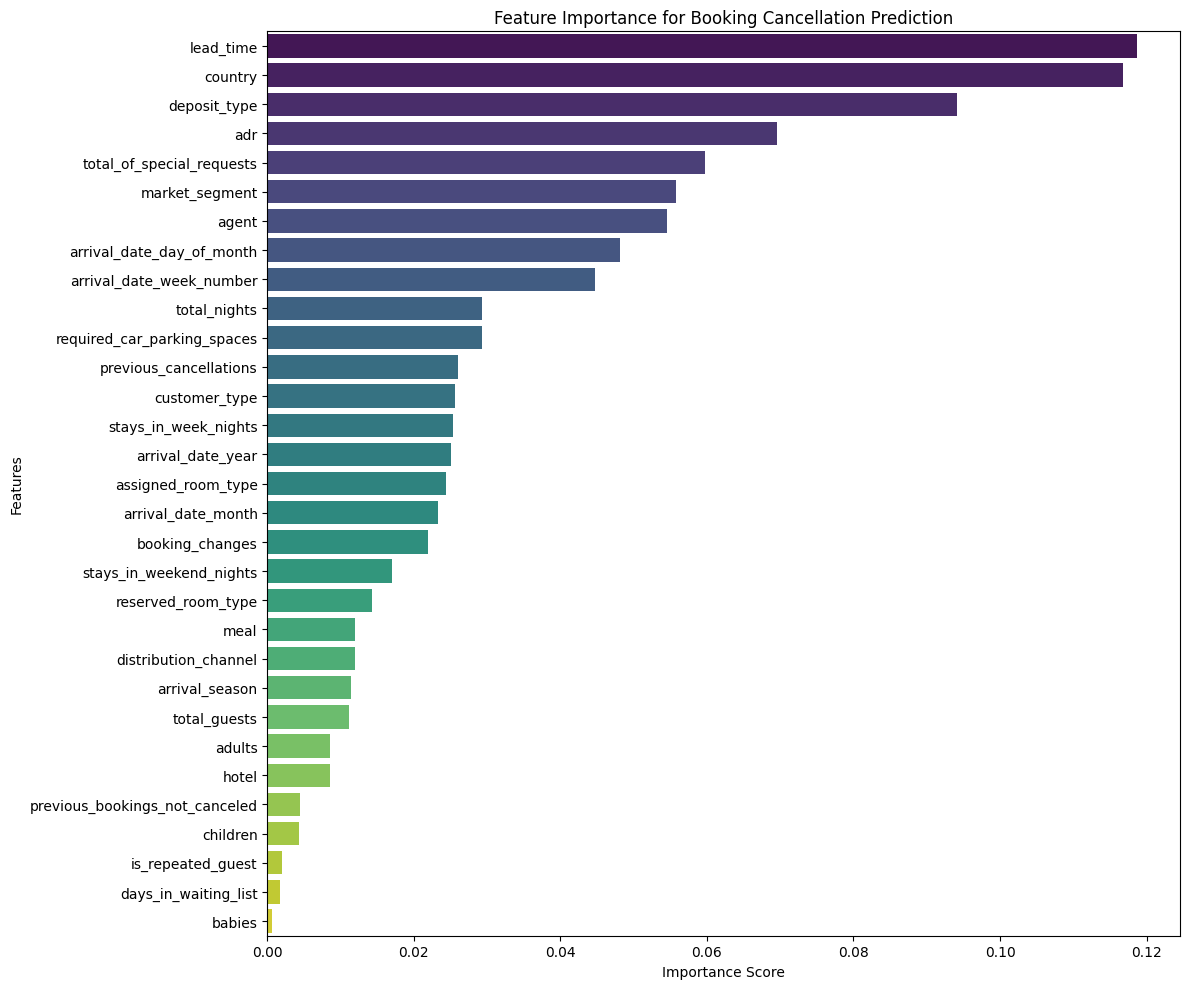

In [84]:

# Get feature importances from the model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Booking Cancellation Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Let's Retrain Model on Selected Number of Features according to the Feature importance

In [85]:
selected_features = [
    'hotel',
    'lead_time',
    'arrival_date_month',
    'market_segment',
    'deposit_type',
    'customer_type',
    'total_guests',
    'total_nights',
    'adr',
    'previous_cancellations',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

X = df[selected_features]
y = df['is_canceled']

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [87]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [88]:
y_pred = model.predict(X_test)

In [89]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8558445365833228
Precision: 0.8384089496581728
Recall   : 0.7589737819286598
F1 Score : 0.7967162768721947

Confusion Matrix
[[13690  1300]
 [ 2142  6745]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.91      0.89     14990
           1       0.84      0.76      0.80      8887

    accuracy                           0.86     23877
   macro avg       0.85      0.84      0.84     23877
weighted avg       0.85      0.86      0.85     23877



# Saving The Model

In [90]:
import joblib
joblib.dump(model, "hotel_cancellation_model.pkl") #==> Saving The Model
joblib.dump(le,"labelEncoder.pkl") #==> Saving The Label Encoder

['labelEncoder.pkl']

# Author: Dhairya Mehta